<a href="https://colab.research.google.com/github/onetti7/awx/blob/devel/Prueba_modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#importo el modelo

In [1]:
!pip install pandas_ta

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import pandas_ta as ta


# Cargar el "cerebro" del bot
modelo = joblib.load('/content/drive/Othercomputers/Mi portátil/GoogleCloud/onettibot/onettibot_v1_PRO.joblib')
print("✅ Modelo cargado correctamente.")

✅ Modelo cargado correctamente.


# Preparacion dataset



## Importamos datasets de kagglehub

### ethereum 2024

In [34]:
import kagglehub
import pandas as pd
import os
#csv_name = "BTC-USD (2014-2024).csv"
csv_name = "Ethereum 2024.csv"
path = kagglehub.dataset_download("kapturovalexander/bitcoin-and-ethereum-prices-from-start-to-2023")

historical_data = pd.read_csv(os.path.join(path,csv_name))

# Convert relevant columns to numeric, handling commas and potential errors
for col in ['Price', 'Open', 'High', 'Low']:
    historical_data[col] = historical_data[col].str.replace(',', '', regex=True).astype(float)

# Function to convert 'Vol.' column with 'K' and 'M' suffixes
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        vol_str = vol_str.replace(',', '')
        if 'M' in vol_str:
            return float(vol_str.replace('M', '')) * 1_000_000
        elif 'K' in vol_str:
            return float(vol_str.replace('K', '')) * 1_000
    return float(vol_str)

historical_data['Vol.'] = historical_data['Vol.'].apply(convert_volume)

# Rename columns as requested
historical_data = historical_data.rename(columns={
    'Price': 'close',
    'High': 'high',
    'Low': 'low',
    'Vol.': 'volume',
    "Open": "open"
})

print(f"The data type of the 'close' column is now: {historical_data['close'].dtype}")
print(f"The data type of the 'volume' column is now: {historical_data['volume'].dtype}")
historical_data.head()

Using Colab cache for faster access to the 'bitcoin-and-ethereum-prices-from-start-to-2023' dataset.


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200.0
1,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700.0
2,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600.0
3,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100.0
4,2014-09-22,399.100006,406.915985,397.130005,402.152008,402.152008,24127600.0


### BTC diario

In [36]:
import kagglehub
import pandas as pd
import os
csv_name = "BTC-USD (2014-2024).csv"
path = kagglehub.dataset_download("kapturovalexander/bitcoin-and-ethereum-prices-from-start-to-2023")

historical_data = pd.read_csv(os.path.join(path,csv_name))

historical_data = historical_data.rename(columns={
    'Close': 'close',
    'High': 'high',
    'Low': 'low',
    'Volume': 'volume',
    "Open": "open"
})
historical_data.head()

Using Colab cache for faster access to the 'bitcoin-and-ethereum-prices-from-start-to-2023' dataset.


,Date,open,high,low,close,Adj Close,volume
0,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200.0
1,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700.0
2,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600.0
3,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100.0
4,2014-09-22,399.100006,406.915985,397.130005,402.152008,402.152008,24127600.0


### BTC 5 min


In [21]:
import kagglehub
import pandas as pd
import os
csv_name = "btc_5m_data.csv"
path = kagglehub.dataset_download("limmhmdl/btcusdt-5min-data")

historical_data = pd.read_csv(os.path.join(path,csv_name))

historical_data = historical_data.rename(columns={
    'Close': 'close',
    'High': 'high',
    'Low': 'low',
    'Volume': 'volume',
    "Open": "open"
})

#historical_data = historical_data.iloc[::-1]
historical_data.head()

Using Colab cache for faster access to the 'btcusdt-5min-data' dataset.


,timestamp,open,high,low,close,volume
0,2025-01-01 00:00:00,93576.00,93702.15,93537.50,93661.20,45.94160
1,2025-01-01 00:05:00,93661.20,93678.02,93600.00,93607.10,71.94585
2,2025-01-01 00:10:00,93607.10,93656.19,93489.03,93656.18,57.96928
3,2025-01-01 00:15:00,93656.19,93840.05,93614.95,93796.35,39.74456
4,2025-01-01 00:20:00,93796.35,93898.05,93707.81,93740.00,38.38053


### Importo dataset de bitget

In [21]:
import datetime
import time
import requests
def get_historical_candles(symbol='BTCUSDT', granularity="5m"):
    """
    Fetches historical candlestick data from the Bitget API by making multiple calls.

    Args:
        symbol (str): The trading symbol (e.g., 'BTCUSDT').
        granularity (str): The candlestick interval (e.g., '5m').

    Returns:
        pandas.DataFrame: A DataFrame with the historical candlestick data, or None if an error occurs.
    """
    # Bitget API endpoint
    url = 'https://api.bitget.com/api/v2/mix/market/history-candles'

    all_data = []
    end_time = int(datetime.datetime.now().timestamp() * 1000)
    contador = 500
    i=0
    while True:
        i+=1
        if i > contador:
          break
        # Parameters for the API request
        params = {
            'productType': 'UMCBL',  # USDT-M Futures
            'symbol': symbol,
            'granularity': granularity,
            'endTime': end_time,
            'limit': 200  # Max limit
        }

        try:
            # Make the GET request
            response = requests.get(url, params=params)
            response.raise_for_status()  # Raise an exception for bad status codes

            data = response.json().get('data', [])
            if not data:
                print("No more data received from the API. Fetching complete.")
                break

            df = pd.DataFrame(data, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume', 'business_volume'])
            all_data.append(df)

            # Update end_time for the next iteration to the timestamp of the first candle received
            first_timestamp = int(df.iloc[0]['timestamp'])
            if first_timestamp == end_time: # Reached the end
                break
            end_time = first_timestamp

            print(f"Fetched {len(data)} candles. Next request ends at {pd.to_datetime(end_time, unit='ms')}")

            # Respect API rate limits
            time.sleep(0.2)

        except requests.exceptions.RequestException as e:
            print(f"An error occurred with the API request: {e}")
            return None
        except Exception as e:
            print(f"An unexpected error occurred: {e}")
            return None

    if not all_data:
        return None

    # Concatenate all dataframes and sort by timestamp
    full_df = pd.concat(all_data).drop_duplicates()
    full_df['timestamp'] = pd.to_numeric(full_df['timestamp'], errors='coerce')
    full_df = full_df.dropna(subset=['timestamp'])
    # Convert timestamp to datetime and set as index
    full_df['timestamp'] = pd.to_datetime(full_df['timestamp'], unit='ms')
    full_df = full_df.sort_values('timestamp')
    full_df.set_index('timestamp', inplace=True)

    # Convert columns to numeric types
    for col in ['open', 'high', 'low', 'close', 'volume', 'business_volume']:
        full_df[col] = pd.to_numeric(full_df[col])

    return full_df

historical_data = get_historical_candles()

Fetched 200 candles. Next request ends at 2026-03-23 00:20:00
Fetched 200 candles. Next request ends at 2026-03-22 07:40:00
Fetched 200 candles. Next request ends at 2026-03-21 15:00:00
Fetched 200 candles. Next request ends at 2026-03-20 22:20:00
Fetched 200 candles. Next request ends at 2026-03-20 05:40:00
Fetched 200 candles. Next request ends at 2026-03-19 13:00:00
Fetched 200 candles. Next request ends at 2026-03-18 20:20:00
Fetched 200 candles. Next request ends at 2026-03-18 03:40:00
Fetched 200 candles. Next request ends at 2026-03-17 11:00:00
Fetched 200 candles. Next request ends at 2026-03-16 18:20:00
Fetched 200 candles. Next request ends at 2026-03-16 01:40:00
Fetched 200 candles. Next request ends at 2026-03-15 09:00:00
Fetched 200 candles. Next request ends at 2026-03-14 16:20:00
Fetched 200 candles. Next request ends at 2026-03-13 23:40:00
Fetched 200 candles. Next request ends at 2026-03-13 07:00:00
Fetched 200 candles. Next request ends at 2026-03-12 14:20:00
Fetched 

## Añadimos campos al dataset


In [22]:
import numpy as np

historical_data['log_returns'] = np.log(historical_data['close'] / historical_data['close'].shift(1))
historical_data['candle_body_log'] = np.log(historical_data['close'] / historical_data['open'])
historical_data['candle_superior'] = (historical_data['high'] - np.maximum(historical_data['open'], historical_data['close'])) / historical_data['close']
historical_data['candle_inferior'] = (np.minimum(historical_data['open'], historical_data['close']) / historical_data['low'])/ historical_data['close']
historical_data['EMA20'] = historical_data['close'].ewm(span=20, adjust=False).mean()
historical_data['EMA50'] = historical_data['close'].ewm(span=50, adjust=False).mean()

historical_data['distancia_ema20'] = np.log(historical_data['close'] / historical_data['EMA20'])
historical_data['distancia_ema50'] = np.log(historical_data['close'] / historical_data['EMA50'])
historical_data['distancia_emas'] = np.log(historical_data['EMA20'] / historical_data['EMA50'])
historical_data['cruce_alcista'] = ((historical_data['distancia_emas'] > 0) & (historical_data['distancia_emas'].shift(1) <= 0)).astype(int)
historical_data['cruce_bajista'] = ((historical_data['distancia_emas'] < 0) & (historical_data['distancia_emas'].shift(1) >= 0)).astype(int)

historical_data['RSI'] = historical_data.ta.rsi()

print(historical_data)

                        open     high      low    close     volume  \
timestamp                                                            
2025-04-10 11:40:00  81724.9  81856.0  81724.9  81819.0   720.8701   
2025-04-10 11:45:00  81819.0  81891.7  81789.4  81846.0   434.3851   
2025-04-10 11:50:00  81846.0  81867.0  81729.3  81800.0   439.9247   
2025-04-10 11:55:00  81800.0  81895.3  81795.1  81839.2   108.6915   
2025-04-10 12:00:00  81839.2  81983.7  81651.3  81771.2  1218.7421   
...                      ...      ...      ...      ...        ...   
2026-03-23 16:35:00  70392.8  70485.8  70345.1  70363.9   158.9879   
2026-03-23 16:40:00  70363.9  70446.8  70337.0  70434.0   106.6826   
2026-03-23 16:45:00  70434.0  70731.3  70394.1  70613.9   585.9738   
2026-03-23 16:50:00  70613.9  70628.3  70510.0  70566.0   220.4554   
2026-03-23 16:55:00  70566.0  70597.8  70466.0  70536.1   108.9996   

                     business_volume  log_returns  candle_body_log  \
timestamp          

In [23]:
from scipy.signal import argrelextrema
from numpy.lib.stride_tricks import sliding_window_view

mostreo = False

def calcular_pendientes_super_rapido(array_precios, ventana, n_picos, mostreo = False):

    n = len(array_precios)

    # 2. Preparamos arrays vacíos para inyectar los resultados
    pendientes_max = np.zeros(len(array_precios))
    pendientes_min = np.zeros(len(array_precios))

    paso = mostreo if (isinstance(mostreo,int) and mostreo >1) else 1
    indices_a_procesar = np.arange(ventana-1,n,paso)

    # 3. UN SOLO BUCLE: Iteramos las ventanas una única vez
    for idx in indices_a_procesar:
        v_actual = array_precios[idx - (ventana-1):idx+1]
        # Encontramos picos en esta ventana
        picos_altos = argrelextrema(v_actual, np.greater, order=n_picos)[0]
        picos_bajos = argrelextrema(v_actual, np.less, order=n_picos)[0]

        # Calculamos pendiente techos (usando polyfit que es más ligero que linregress)
        if len(picos_altos) >= 2:
            valores_altos = v_actual[picos_altos]
            pendientes_max[idx] = np.polyfit(picos_altos, valores_altos, 1)[0]

        # Calculamos pendiente suelos
        if len(picos_bajos) >= 2:
            valores_bajos = v_actual[picos_bajos]
            pendientes_min[idx] = np.polyfit(picos_bajos, valores_bajos, 1)[0]
    if paso > 1:
        pendientes_max = pd.Series(pendientes_max).replace(0, np.nan).ffill().fillna(0).values
        pendientes_min = pd.Series(pendientes_min).replace(0, np.nan).ffill().fillna(0).values
    return pendientes_max, pendientes_min

# --- EJECUCIÓN ---

# Parámetros
ventana = 200
n_picos = 50

# Extraemos solo los números brutos (.values) para escapar de la lentitud de Pandas
precios_crudos = historical_data['close'].values

# Ejecutamos la función optimizada
maximos, minimos = calcular_pendientes_super_rapido(precios_crudos, ventana, n_picos, mostreo)

# Asignamos los resultados de golpe al DataFrame
historical_data['pendientes_maximos'] = maximos
historical_data['pendientes_minimos'] = minimos


#Añadimos resultados para comprobar estrategia a futuro

In [24]:
historical_data['Ben_1'] = np.log(historical_data['close'].shift(-1) / historical_data['close'])
historical_data['Ben_5'] = np.log(historical_data['close'].shift(-5) / historical_data['close'])
historical_data['Ben_10'] = np.log(historical_data['close'].shift(-10) / historical_data['close'])
historical_data['Ben_20'] = np.log(historical_data['close'].shift(-20) / historical_data['close'])

print(historical_data)


                        open     high      low    close     volume  \
timestamp                                                            
2025-04-10 11:40:00  81724.9  81856.0  81724.9  81819.0   720.8701   
2025-04-10 11:45:00  81819.0  81891.7  81789.4  81846.0   434.3851   
2025-04-10 11:50:00  81846.0  81867.0  81729.3  81800.0   439.9247   
2025-04-10 11:55:00  81800.0  81895.3  81795.1  81839.2   108.6915   
2025-04-10 12:00:00  81839.2  81983.7  81651.3  81771.2  1218.7421   
...                      ...      ...      ...      ...        ...   
2026-03-23 16:35:00  70392.8  70485.8  70345.1  70363.9   158.9879   
2026-03-23 16:40:00  70363.9  70446.8  70337.0  70434.0   106.6826   
2026-03-23 16:45:00  70434.0  70731.3  70394.1  70613.9   585.9738   
2026-03-23 16:50:00  70613.9  70628.3  70510.0  70566.0   220.4554   
2026-03-23 16:55:00  70566.0  70597.8  70466.0  70536.1   108.9996   

                     business_volume  log_returns  candle_body_log  \
timestamp          

# Ejecutamos inferencia

In [38]:
import pandas as pd
import numpy as np
import joblib

def ejecutar_inferencia(df_nuevo, modelo, umbral_compra=0.53, umbral_venta=0.47):
    """
    Toma un dataset nuevo, carga el modelo y devuelve las señales de trading.
    """

    columnas_modelo = modelo.get_booster().feature_names


    # 2. Preprocesamiento: Asegurar que el tiempo sea numérico
    # Si tu modelo usó estas variables, las recreamos aquí
    df_proceso = df_nuevo.copy()

    # 3. Limpieza de Nulos (Crucial para indicadores técnicos como EMAs o RSI)
    df_proceso = df_proceso.dropna(subset=columnas_modelo)

    # 4. Selección y Alineación Estricta
    # Esto garantiza que X tenga las columnas en el MISMO orden que el entrenamiento
    try:
        X = df_proceso[columnas_modelo]
    except KeyError as e:
        columnas_faltantes = set(columnas_modelo) - set(df_proceso.columns)
        return f"❌ Error: Al dataset nuevo le faltan estas columnas: {columnas_faltantes}"

    # 5. Predicción
    predicciones = modelo.predict(X)

    # 6. Construcción del DataFrame de salida
    resultado = pd.DataFrame(index=X.index)
    resultado['close'] = df_proceso['close'] # Para referencia de precio
    resultado['probabilidad'] = predicciones

    # Aplicar lógica de señales
    resultado['señal'] = 'ESPERAR'
    resultado.loc[resultado['probabilidad'] >= umbral_compra, 'señal'] = 'COMPRA'
    resultado.loc[resultado['probabilidad'] <= umbral_venta, 'señal'] = 'VENTA'

    return resultado

informe = ejecutar_inferencia(historical_data, modelo)
print(informe['señal'].value_counts())
print(informe)


señal
ESPERAR    99895
VENTA         71
COMPRA        33
Name: count, dtype: int64
                       close  probabilidad    señal
timestamp                                          
2025-04-10 11:45:00  81846.0      0.504248  ESPERAR
2025-04-10 11:50:00  81800.0      0.504173  ESPERAR
2025-04-10 11:55:00  81839.2      0.504248  ESPERAR
2025-04-10 12:00:00  81771.2      0.503453  ESPERAR
2025-04-10 12:05:00  81627.3      0.502762  ESPERAR
...                      ...           ...      ...
2026-03-23 16:35:00  70363.9      0.500102  ESPERAR
2026-03-23 16:40:00  70434.0      0.499935  ESPERAR
2026-03-23 16:45:00  70613.9      0.499608  ESPERAR
2026-03-23 16:50:00  70566.0      0.499935  ESPERAR
2026-03-23 16:55:00  70536.1      0.499935  ESPERAR

[99999 rows x 3 columns]


#Generamos reporte


🚀 Iniciando Simulación | Capital: 1000€ | Timeout: 20 velas


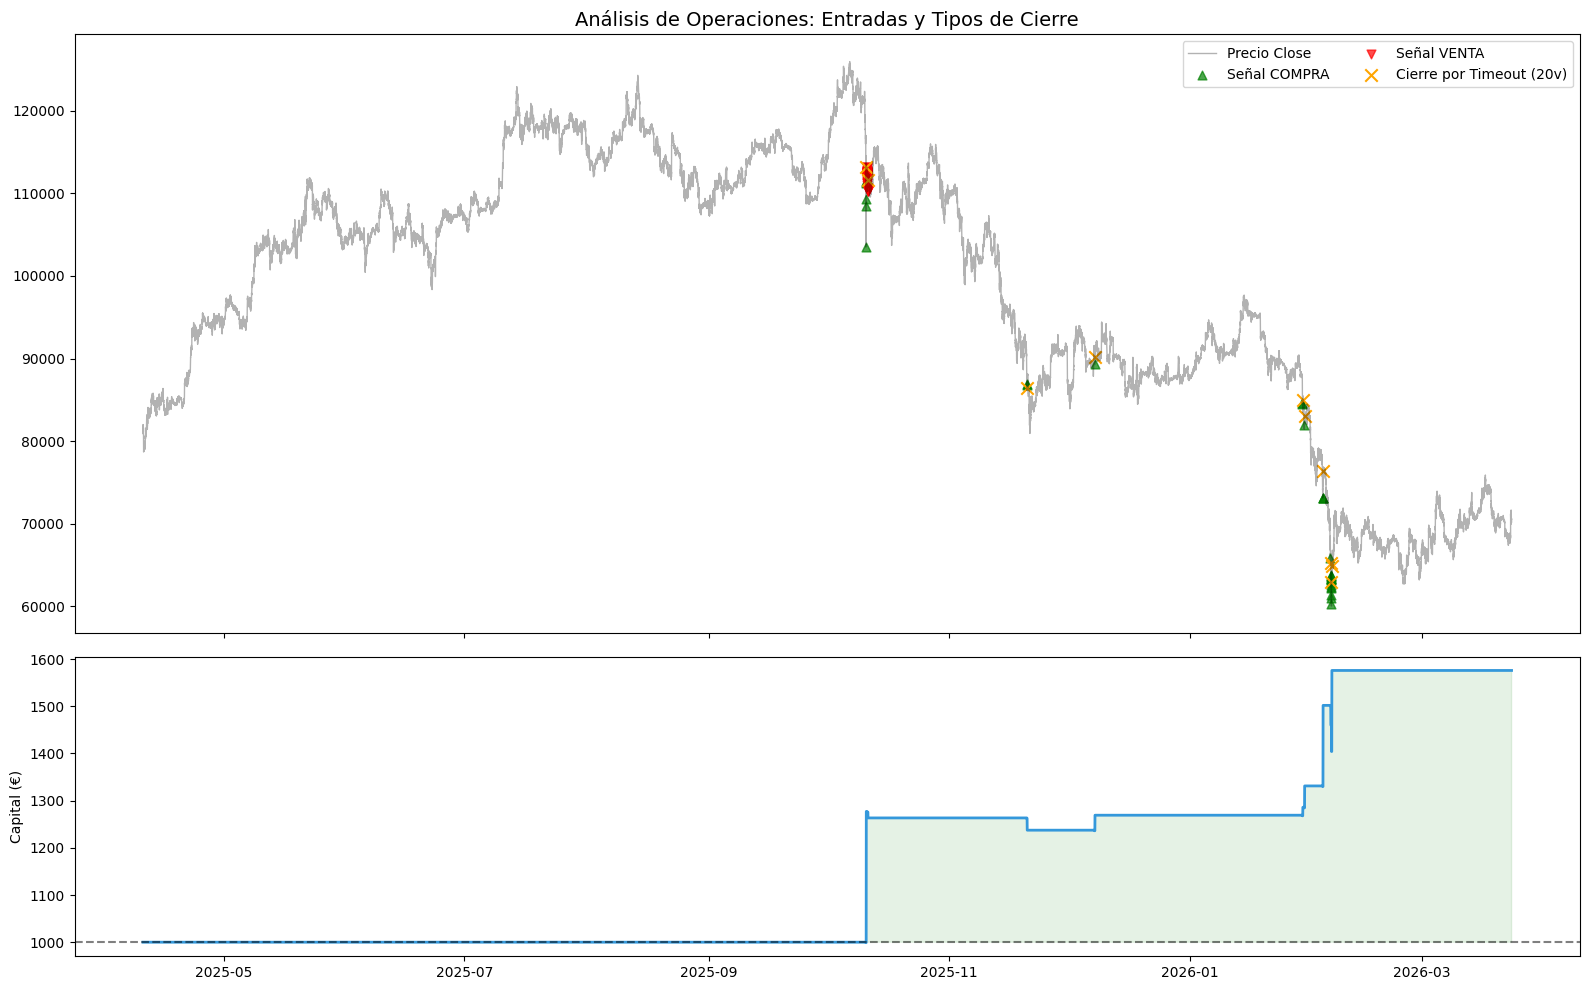

🏁 Resultado: 1575.83€ | Retorno: 57.58%
                       close  probabilidad    señal  wallet_euro
timestamp                                                       
2025-04-10 11:45:00  81846.0      0.504248  ESPERAR  1000.000000
2025-04-10 11:50:00  81800.0      0.504173  ESPERAR  1000.000000
2025-04-10 11:55:00  81839.2      0.504248  ESPERAR  1000.000000
2025-04-10 12:00:00  81771.2      0.503453  ESPERAR  1000.000000
2025-04-10 12:05:00  81627.3      0.502762  ESPERAR  1000.000000
...                      ...           ...      ...          ...
2026-03-23 16:35:00  70363.9      0.500102  ESPERAR  1575.827583
2026-03-23 16:40:00  70434.0      0.499935  ESPERAR  1575.827583
2026-03-23 16:45:00  70613.9      0.499608  ESPERAR  1575.827583
2026-03-23 16:50:00  70566.0      0.499935  ESPERAR  1575.827583
2026-03-23 16:55:00  70536.1      0.499935  ESPERAR  1575.827583

[99999 rows x 4 columns]


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def simulador_estrategia_dinamica(df_input, capital_inicial=1000, apalancamiento=1, comision=0.001, timeout=20):
    df = df_input.copy()

    # Variables de estado
    capital = float(capital_inicial)
    posicion = 0 # 0: Cash, 1: Long, -1: Short
    precio_entrada = 0.0
    velas_restantes = 0 # Cronómetro regresivo

    historial_capital = []
    # Registros para el gráfico
    registros_cierre_señal = []
    registros_cierre_tiempo = []

    precios = df['close'].values
    senales = df['señal'].values
    indices = df.index

    print(f"🚀 Iniciando Simulación | Capital: {capital_inicial}€ | Timeout: {timeout} velas")

    for i in range(len(df)):
        precio_actual = precios[i]
        señal_actual = senales[i]

        # --- 1. GESTIÓN DE POSICIÓN ABIERTA ---
        if posicion != 0:
            velas_restantes -= 1
            rendimiento = (precio_actual / precio_entrada) - 1
            pnl_relativo = (rendimiento if posicion == 1 else -rendimiento) * apalancamiento

            # Condición A: Señal Contraria (Cerrar y Revertir)
            señal_contraria = (posicion == 1 and señal_actual == 'VENTA') or \
                              (posicion == -1 and señal_actual == 'COMPRA')

            # Condición B: Misma Señal (Resetear cronómetro)
            misma_señal = (posicion == 1 and señal_actual == 'COMPRA') or \
                          (posicion == -1 and señal_actual == 'VENTA')

            # Condición C: Se acaba el tiempo
            tiempo_agotado = (velas_restantes <= 0)

            if señal_contraria or tiempo_agotado:
                # Calculamos cierre
                capital = capital * (1 + pnl_relativo)
                capital -= capital * comision # Comisión de salida

                if señal_contraria:
                    registros_cierre_señal.append((indices[i], precio_actual))
                else:
                    registros_cierre_tiempo.append((indices[i], precio_actual))

                posicion = 0 # Volvemos a Cash (temporalmente si hay reversión)

            elif misma_señal:
                # Extendemos la vida de la posición
                velas_restantes = timeout

        # --- 2. APERTURA DE NUEVA POSICIÓN ---
        if posicion == 0 and capital > 0:
            if señal_actual == 'COMPRA':
                capital -= capital * comision # Comisión entrada
                posicion = 1
                precio_entrada = precio_actual
                velas_restantes = timeout
            elif señal_actual == 'VENTA':
                capital -= capital * comision # Comisión entrada
                posicion = -1
                precio_entrada = precio_actual
                velas_restantes = timeout

        historial_capital.append(max(0.0, capital))

    df['wallet_euro'] = historial_capital

    # --- 3. GRÁFICO PROFESIONAL ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # Superior: Precio y Eventos
    ax1.plot(df.index, df['close'], color='black', alpha=0.3, lw=1, label='Precio Close')

    # Entradas
    idx_c = df[df['señal'] == 'COMPRA'].index
    idx_v = df[df['señal'] == 'VENTA'].index
    ax1.scatter(idx_c, df.loc[idx_c, 'close'], marker='^', color='green', s=40, label='Señal COMPRA', alpha=0.7)
    ax1.scatter(idx_v, df.loc[idx_v, 'close'], marker='v', color='red', s=40, label='Señal VENTA', alpha=0.7)

    # Cierres
    if registros_cierre_señal:
        idx_cs, pre_cs = zip(*registros_cierre_señal)
        ax1.scatter(idx_cs, pre_cs, marker='x', color='blue', s=80, label='Cierre por Señal Contraria')
    if registros_cierre_tiempo:
        idx_ct, pre_ct = zip(*registros_cierre_tiempo)
        ax1.scatter(idx_ct, pre_ct, marker='x', color='orange', s=80, label='Cierre por Timeout (20v)')

    ax1.set_title("Análisis de Operaciones: Entradas y Tipos de Cierre", fontsize=14)
    ax1.legend(loc='best', ncol=2)

    # Inferior: Capital
    ax2.plot(df.index, df['wallet_euro'], color='#3498db', lw=2, label='Capital Neto (€)')
    ax2.axhline(y=capital_inicial, color='black', linestyle='--', alpha=0.5)
    ax2.fill_between(df.index, df['wallet_euro'], capital_inicial, where=(df['wallet_euro'] >= capital_inicial), color='green', alpha=0.1)
    ax2.fill_between(df.index, df['wallet_euro'], capital_inicial, where=(df['wallet_euro'] < capital_inicial), color='red', alpha=0.1)
    ax2.set_ylabel("Capital (€)")

    plt.tight_layout()
    plt.show()

    print(f"🏁 Resultado: {capital:.2f}€ | Retorno: {((capital/capital_inicial)-1)*100:.2f}%")
    return df

# --- EJECUCIÓN ---
resultado = simulador_estrategia_dinamica(informe, capital_inicial=1000, apalancamiento=3, timeout=20)
print(resultado)